# W1-D2 Log Mining + Parsing + Anomaly from Log

**Dataset:** HDFS_2k.log (Loghub HDFS sample, 2000 lines)  
**Tools:** Drain3, Pandas, NumPy, Matplotlib, Scikit-learn  

> ⚠️ **Note on Precision/Recall:** The HDFS_2k sample does **not** include `anomaly_label.csv`, so precision/recall cannot be computed reliably. Unsupervised anomaly candidates (3-sigma spikes) are reported instead.

In [1]:
# ==============================================================
# Setup: imports and directory configuration
# ==============================================================
import os
import re
import sys
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from drain3 import TemplateMiner
from drain3.template_miner_config import TemplateMinerConfig
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

matplotlib.rcParams['figure.dpi'] = 120
matplotlib.rcParams['font.size'] = 10

# Paths — all relative to this notebook
BASE_DIR   = Path('.').resolve()
DATA_DIR   = BASE_DIR / 'data'
RESULTS_DIR = BASE_DIR / 'results'
SHOTS_DIR  = BASE_DIR / 'screenshots'

for d in [RESULTS_DIR, SHOTS_DIR]:
    d.mkdir(exist_ok=True)

LOG_FILE = DATA_DIR / 'HDFS_2k.log'
print(f'BASE_DIR   : {BASE_DIR}')
print(f'LOG_FILE   : {LOG_FILE}')
print(f'Log exists : {LOG_FILE.exists()}')

BASE_DIR   : D:\Downloads\VS_WorkSpace\AWS\aiops\w1\day-2
LOG_FILE   : D:\Downloads\VS_WorkSpace\AWS\aiops\w1\day-2\data\HDFS_2k.log
Log exists : True


---
## Phase 1: Parse Log with Drain3

### Helper functions

In [2]:
def create_miner(sim_th=0.5, depth=4):
    """Create and configure a Drain3 TemplateMiner."""
    config = TemplateMinerConfig()
    config.drain_sim_th = sim_th
    config.drain_depth = depth
    config.drain_max_children = 100
    config.parametrize_numeric_tokens = True
    return TemplateMiner(config=config)


def parse_hdfs_timestamp(line):
    """
    Parse HDFS timestamp from log line.
    Format: YYMMDD HHMMSS  (e.g. '081109 203518 ...')
    Returns pd.Timestamp or pd.NaT if parsing fails.
    """
    try:
        parts = line.split()
        if len(parts) >= 2:
            date_str, time_str = parts[0], parts[1]
            if len(date_str) == 6 and len(time_str) == 6:
                return pd.Timestamp(
                    datetime.strptime(f'20{date_str} {time_str}', '%Y%m%d %H%M%S')
                )
    except Exception:
        pass
    return pd.NaT


def extract_block_id(line):
    """
    Extract block ID matching pattern blk_-?\d+.
    Returns the first match as string, or None.
    """
    m = re.search(r'blk_-?\d+', line)
    return m.group(0) if m else None


def parse_logs_with_drain(log_lines, sim_th=0.5):
    """
    Parse a list of log lines with Drain3.
    Returns (parsed_df, template_df).
    """
    miner = create_miner(sim_th=sim_th)
    records = []
    for i, line in enumerate(log_lines):
        if not line.strip():
            continue
        result = miner.add_log_message(line)
        records.append({
            'line_id'    : i + 1,
            'raw_log'    : line,
            'timestamp'  : parse_hdfs_timestamp(line),
            'block_id'   : extract_block_id(line),
            'template_id': result['cluster_id'],
            'template'   : result['template_mined'],
            'change_type': result['change_type'],
        })

    parsed_df = pd.DataFrame(records)

    template_df = (
        parsed_df
        .groupby(['template_id', 'template'])
        .size()
        .reset_index(name='count')
        .sort_values('count', ascending=False)
        .reset_index(drop=True)
    )
    return parsed_df, template_df

print('Helper functions defined.')

Helper functions defined.


### Load and parse HDFS_2k.log

In [3]:
with open(LOG_FILE, 'r', encoding='utf-8', errors='replace') as f:
    raw_lines = [l.rstrip('\n\r') for l in f.readlines()]

print(f'Total log lines read : {len(raw_lines)}')
print('\nFirst 3 lines:')
for ln in raw_lines[:3]:
    print(f'  {ln}')

Total log lines read : 2000

First 3 lines:
  081109 203615 148 INFO dfs.DataNode$PacketResponder: PacketResponder 1 for block blk_38865049064139660 terminating
  081109 203807 222 INFO dfs.DataNode$PacketResponder: PacketResponder 0 for block blk_-6952295868487656571 terminating
  081109 204005 35 INFO dfs.FSNamesystem: BLOCK* NameSystem.addStoredBlock: blockMap updated: 10.251.73.220:50010 is added to blk_7128370237687728475 size 67108864


In [4]:
parsed_df, template_df = parse_logs_with_drain(raw_lines, sim_th=0.5)

print(f'Parsed rows          : {len(parsed_df)}')
print(f'Unique template IDs  : {parsed_df["template_id"].nunique()}')
print()
print('Columns of parsed_df :', list(parsed_df.columns))
parsed_df.head(3)

Parsed rows          : 2000
Unique template IDs  : 21

Columns of parsed_df : ['line_id', 'raw_log', 'timestamp', 'block_id', 'template_id', 'template', 'change_type']


,line_id,raw_log,timestamp,block_id,template_id,template,change_type
0,1,081109 203615 148 INFO dfs.DataNode$PacketResp...,2008-11-09 20:36:15,blk_38865049064139660,1,081109 203615 148 INFO dfs.DataNode$PacketResp...,cluster_created
1,2,081109 203807 222 INFO dfs.DataNode$PacketResp...,2008-11-09 20:38:07,blk_-6952295868487656571,1,081109 <*> <*> INFO dfs.DataNode$PacketRespond...,cluster_template_changed
2,3,081109 204005 35 INFO dfs.FSNamesystem: BLOCK*...,2008-11-09 20:40:05,blk_7128370237687728475,2,081109 204005 35 INFO dfs.FSNamesystem: BLOCK*...,cluster_created


### Top-10 Templates

In [5]:
top10 = template_df.head(10).copy()
top10.to_csv(RESULTS_DIR / 'top_templates.csv', index=False)
print('Saved: results/top_templates.csv')
print()
print(top10[['template_id', 'count', 'template']].to_string(index=False))

Saved: results/top_templates.csv

 template_id  count                                                                                                            template
           1    286                        <*> <*> <*> INFO dfs.DataNode$PacketResponder: PacketResponder <*> for block <*> terminating
           2    286 <*> <*> <*> INFO dfs.FSNamesystem: BLOCK* NameSystem.addStoredBlock: blockMap updated: <*> is added to <*> size <*>
           4    268                                   <*> <*> <*> INFO dfs.DataNode$DataXceiver: Receiving block <*> src: <*> dest: <*>
           3    260                              <*> <*> <*> INFO dfs.DataNode$PacketResponder: Received block <*> of size <*> from <*>
           7    260                                                         <*> <*> <*> INFO dfs.FSDataset: Deleting block <*> file <*>
          11    121                   081110 <*> <*> INFO dfs.FSNamesystem: BLOCK* NameSystem.delete: <*> is added to invalidSet of <*>
          11  

---
## Drain3 Tuning

We test `sim_th` values: **0.3**, **0.5**, **0.7**

- **0.3** — aggressive merge → fewer, broader templates, may lose detail  
- **0.5** — balanced (chosen as default)  
- **0.7** — fine-grained split → more templates, may over-fragment

In [6]:
tuning_rows = []
for sim_th in [0.3, 0.5, 0.7]:
    _, tdf = parse_logs_with_drain(raw_lines, sim_th=sim_th)
    top_row = tdf.iloc[0]
    tuning_rows.append({
        'sim_th'            : sim_th,
        'num_templates'     : len(tdf),
        'top_template_count': int(top_row['count']),
        'top_template'      : top_row['template'],
    })
    print(f'sim_th={sim_th:.1f}  → {len(tdf):3d} templates')

tuning_df = pd.DataFrame(tuning_rows)
tuning_df.to_csv(RESULTS_DIR / 'drain_tuning.csv', index=False)
print('\nSaved: results/drain_tuning.csv')
print(tuning_df)

sim_th=0.3  →  41 templates
sim_th=0.5  →  48 templates


sim_th=0.7  → 916 templates

Saved: results/drain_tuning.csv
   sim_th  num_templates  top_template_count  \
0     0.3             41                 286   
1     0.5             48                 286   
2     0.7            916                 135   

                                        top_template  
0  <*> <*> <*> INFO dfs.DataNode$PacketResponder:...  
1  <*> <*> <*> INFO dfs.DataNode$PacketResponder:...  
2  081111 <*> <*> INFO dfs.FSNamesystem: BLOCK* N...  


**Chosen:** `best_sim_th = 0.5`  
It provides a good balance — does not aggressively merge unrelated patterns (0.3) nor produce excessive fragmentation (0.7).

In [7]:
best_sim_th = 0.5
# parsed_df already uses sim_th=0.5, so no re-parse needed
print(f'Using best_sim_th = {best_sim_th}')

Using best_sim_th = 0.5


---
## Phase 2: Anomaly Detection on Log

### 2.1 Template Count Time Series (5-min windows)

In [8]:
ts_df = parsed_df.dropna(subset=['timestamp']).copy()
ts_df['time_window'] = ts_df['timestamp'].dt.floor('5min')

timeseries = (
    ts_df.groupby(['time_window', 'template_id'])
    .size()
    .unstack(fill_value=0)
)

timeseries.index = pd.DatetimeIndex(timeseries.index)
timeseries.to_csv(RESULTS_DIR / 'template_count_timeseries.csv')
print(f'Time windows: {len(timeseries)}')
print(f'Template columns: {timeseries.shape[1]}')
print('Saved: results/template_count_timeseries.csv')
timeseries.head()

Time windows: 305
Template columns: 21
Saved: results/template_count_timeseries.csv


template_id,1,2,3,4,5,6,7,8,9,10,...,12,13,14,15,16,17,18,19,20,21
time_window,,,,,,,,,,,,,,,,,,,,,
2008-11-09 20:35:00,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2008-11-09 20:40:00,2,4,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2008-11-09 20:45:00,1,1,2,3,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2008-11-09 20:50:00,1,1,2,0,2,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2008-11-09 20:55:00,0,3,2,1,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### 2.2 Plot Top-5 Template Count Time Series

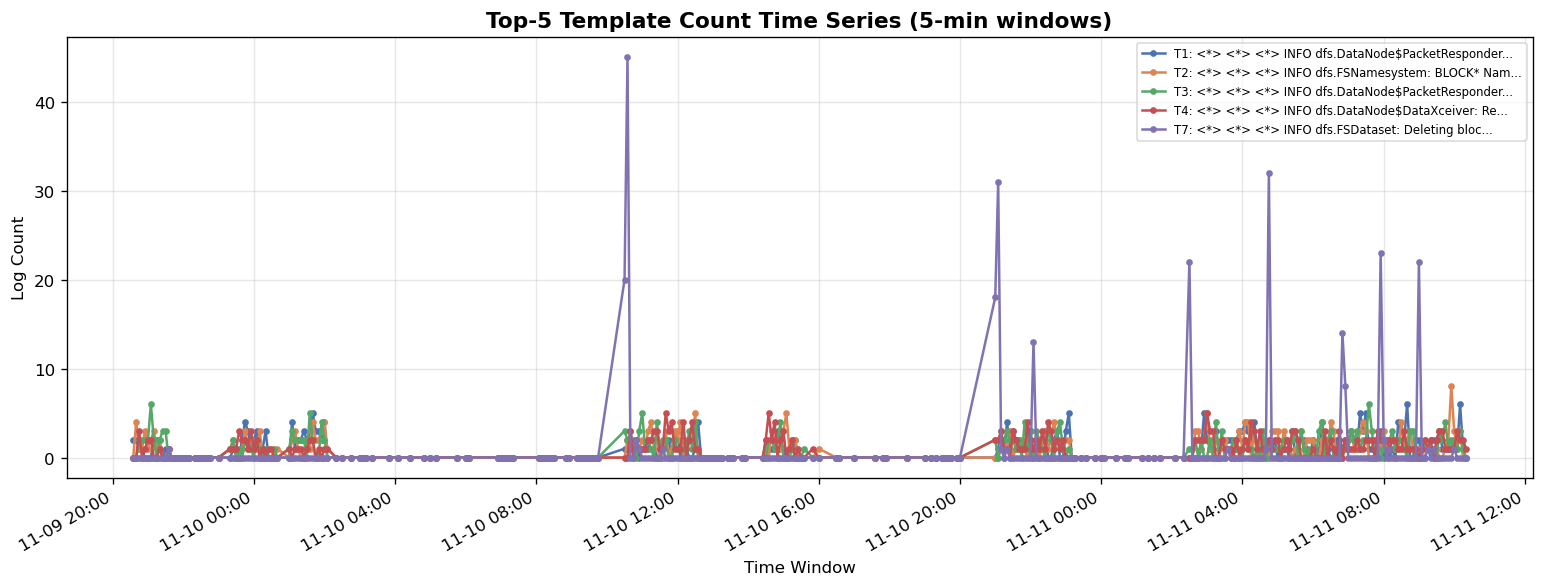

Saved: screenshots/template_count_timeseries.png


In [9]:
top5_ids = template_df.head(5)['template_id'].tolist()
top5_cols = [c for c in timeseries.columns if c in top5_ids]

fig, ax = plt.subplots(figsize=(13, 5))
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']
for i, tid in enumerate(top5_cols):
    label = f'T{tid}: {template_df[template_df["template_id"]==tid]["template"].values[0][:45]}...'
    ax.plot(
        timeseries.index, timeseries[tid],
        color=colors[i % len(colors)], linewidth=1.5,
        marker='o', markersize=3, label=label
    )

ax.set_title('Top-5 Template Count Time Series (5-min windows)', fontsize=13, fontweight='bold')
ax.set_xlabel('Time Window')
ax.set_ylabel('Log Count')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
fig.autofmt_xdate()
ax.legend(fontsize=7, loc='upper right', framealpha=0.7)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(SHOTS_DIR / 'template_count_timeseries.png', bbox_inches='tight')
plt.show()
print('Saved: screenshots/template_count_timeseries.png')

### 2.3 Spike Detection — 3-Sigma Rule

In [10]:
spike_records = []
for tid in timeseries.columns:
    series = timeseries[tid]
    mean_val = series.mean()
    std_val  = series.std()
    if std_val == 0 or np.isnan(std_val):
        continue
    for ts_win, count_val in series.items():
        z = (count_val - mean_val) / std_val
        if z > 3.0:
            spike_records.append({
                'timestamp'  : ts_win,
                'template_id': tid,
                'count'      : count_val,
                'mean'       : round(mean_val, 4),
                'std'        : round(std_val, 4),
                'z_score'    : round(z, 4),
                'template'   : template_df[template_df['template_id']==tid]['template'].values[0]
                               if len(template_df[template_df['template_id']==tid]) > 0 else '',
            })

spikes_df = pd.DataFrame(spike_records)
if not spikes_df.empty:
    spikes_df = spikes_df.sort_values('z_score', ascending=False)

spikes_df.to_csv(RESULTS_DIR / 'template_spikes_3sigma.csv', index=False)
print(f'Spikes detected: {len(spikes_df)}')
print('Saved: results/template_spikes_3sigma.csv')
spikes_df.head(10)

Spikes detected: 117
Saved: results/template_spikes_3sigma.csv


,timestamp,template_id,count,mean,std,z_score,template
87,2008-11-10 21:15:00,13,1,0.0033,0.0573,17.4070,081110 211541 18 INFO dfs.DataNode: 10.250.15....
116,2008-11-11 09:15:00,21,1,0.0033,0.0573,17.4070,081111 091733 19 INFO dfs.FSNamesystem: BLOCK*...
115,2008-11-11 08:05:00,20,1,0.0033,0.0573,17.4070,081111 080934 19 INFO dfs.FSNamesystem: BLOCK*...
114,2008-11-11 06:50:00,19,1,0.0033,0.0573,17.4070,081111 065303 19 INFO dfs.FSNamesystem: BLOCK*...
113,2008-11-11 06:50:00,18,1,0.0033,0.0573,17.4070,081111 065254 19 INFO dfs.FSNamesystem: BLOCK*...
51,2008-11-09 21:35:00,8,3,0.0295,0.2346,12.6608,081109 <*> <*> INFO dfs.DataNode$DataXceiver: ...
73,2008-11-10 10:30:00,11,64,0.7344,5.0038,12.6436,081110 <*> <*> INFO dfs.FSNamesystem: BLOCK* N...
89,2008-11-10 22:15:00,14,1,0.0066,0.0808,12.2883,081110 212510 19 INFO dfs.FSNamesystem: BLOCK*...
88,2008-11-10 21:25:00,14,1,0.0066,0.0808,12.2883,081110 212510 19 INFO dfs.FSNamesystem: BLOCK*...
111,2008-11-11 05:00:00,17,1,0.0066,0.0808,12.2883,081111 050334 20441 INFO dfs.DataNode$DataXcei...


### 2.4 Anomaly Highlighted Plot

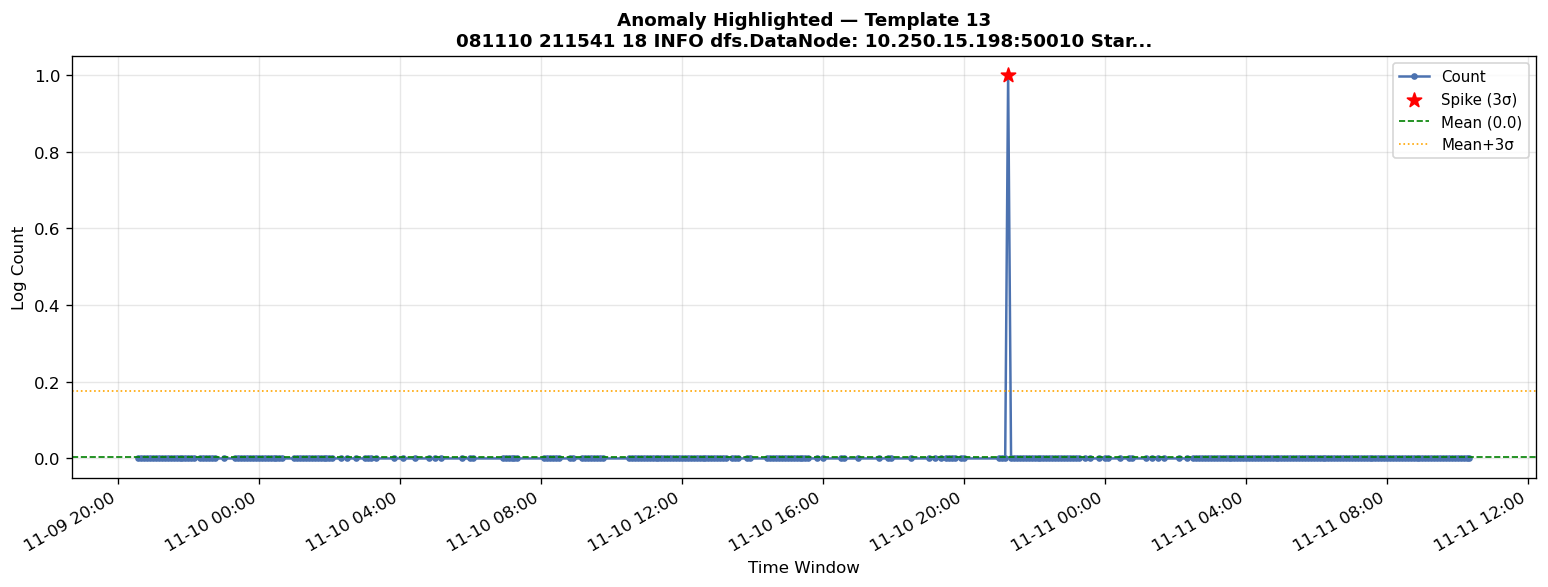

Saved: screenshots/anomaly_highlighted.png


In [11]:
fig, ax = plt.subplots(figsize=(13, 5))

if not spikes_df.empty:
    top_spike_tid = spikes_df.iloc[0]['template_id']
    top_spike_tmpl = spikes_df.iloc[0]['template']
    series = timeseries[top_spike_tid]

    ax.plot(series.index, series.values, color='#4C72B0', linewidth=1.5,
            marker='o', markersize=3, label='Count')

    spike_times = spikes_df[spikes_df['template_id']==top_spike_tid]['timestamp']
    spike_counts = series[series.index.isin(spike_times)]

    ax.scatter(spike_counts.index, spike_counts.values,
               color='red', zorder=5, s=80, marker='*', label='Spike (3σ)')

    mean_val = series.mean()
    std_val  = series.std()
    ax.axhline(mean_val, color='green', linestyle='--', linewidth=1, label=f'Mean ({mean_val:.1f})')
    ax.axhline(mean_val + 3*std_val, color='orange', linestyle=':', linewidth=1, label='Mean+3σ')

    title_tmpl = top_spike_tmpl[:60] + ('...' if len(top_spike_tmpl) > 60 else '')
    ax.set_title(f'Anomaly Highlighted — Template {top_spike_tid}\n{title_tmpl}',
                 fontsize=11, fontweight='bold')
else:
    # Fallback: plot top template, no spike
    top_tid = template_df.iloc[0]['template_id']
    top_tmpl = template_df.iloc[0]['template']
    if top_tid in timeseries.columns:
        series = timeseries[top_tid]
        ax.plot(series.index, series.values, color='#4C72B0', linewidth=1.5, marker='o', markersize=3)
        title_tmpl = top_tmpl[:60] + ('...' if len(top_tmpl) > 60 else '')
        ax.set_title(f'Template {top_tid} — No 3-sigma spike detected\n{title_tmpl}',
                     fontsize=11, fontweight='bold')
        ax.text(0.5, 0.95, 'No 3-sigma spike detected', transform=ax.transAxes,
                ha='center', va='top', fontsize=12, color='grey', style='italic')
    else:
        ax.text(0.5, 0.5, 'No 3-sigma spike detected', transform=ax.transAxes,
                ha='center', va='center', fontsize=14, color='grey')
        ax.set_title('Anomaly Highlighted — No 3-sigma spike detected')

ax.set_xlabel('Time Window')
ax.set_ylabel('Log Count')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
fig.autofmt_xdate()
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(SHOTS_DIR / 'anomaly_highlighted.png', bbox_inches='tight')
plt.show()
print('Saved: screenshots/anomaly_highlighted.png')

### 2.5 New Template Detection (First-Seen Timestamps)

In [12]:
first_seen_df = (
    parsed_df.dropna(subset=['timestamp'])
    .groupby(['template_id', 'template'])['timestamp']
    .min()
    .reset_index()
    .rename(columns={'timestamp': 'first_seen'})
    .sort_values('first_seen')
    .reset_index(drop=True)
)

first_seen_df.to_csv(RESULTS_DIR / 'new_templates_first_seen.csv', index=False)
print('Saved: results/new_templates_first_seen.csv')
print(f'Total unique templates with timestamps: {len(first_seen_df)}')

print('\n--- 10 templates that appeared EARLIEST ---')
print(first_seen_df.head(10)[['template_id', 'first_seen', 'template']].to_string(index=False))

print('\n--- 10 templates that appeared LATEST ---')
print(first_seen_df.tail(10)[['template_id', 'first_seen', 'template']].to_string(index=False))

Saved: results/new_templates_first_seen.csv
Total unique templates with timestamps: 48

--- 10 templates that appeared EARLIEST ---
 template_id          first_seen                                                                                                                                                                    template
           1 2008-11-09 20:36:15                                                          081109 203615 148 INFO dfs.DataNode$PacketResponder: PacketResponder 1 for block blk_38865049064139660 terminating
           1 2008-11-09 20:38:07                                                                             081109 <*> <*> INFO dfs.DataNode$PacketResponder: PacketResponder <*> for block <*> terminating
           2 2008-11-09 20:40:05           081109 204005 35 INFO dfs.FSNamesystem: BLOCK* NameSystem.addStoredBlock: blockMap updated: 10.251.73.220:50010 is added to blk_7128370237687728475 size 67108864
           2 2008-11-09 20:41:32                

### 2.6 Precision / Recall (optional — requires anomaly_label.csv)

> **Note:** The HDFS_2k sample does **not** include `anomaly_label.csv`. Therefore, precision/recall cannot be computed reliably. We create the output CSV with a descriptive note instead.

In [13]:
LABEL_FILE = DATA_DIR / 'anomaly_label.csv'

if LABEL_FILE.exists():
    from sklearn.metrics import precision_score, recall_score, f1_score

    label_df = pd.read_csv(LABEL_FILE)
    # Normalize columns
    label_df.columns = [c.strip() for c in label_df.columns]
    label_df = label_df.rename(columns={c: c.lower().replace(' ', '_') for c in label_df.columns})
    # Try common column names
    block_col = next((c for c in label_df.columns if 'block' in c.lower()), label_df.columns[0])
    label_col = next((c for c in label_df.columns if 'label' in c.lower()), label_df.columns[1])
    label_df = label_df.rename(columns={block_col: 'BlockId', label_col: 'Label'})
    label_df['y_true'] = (label_df['Label'].str.lower() == 'anomaly').astype(int)

    # Map spike blocks to predictions
    spike_block_ids = set()
    if not spikes_df.empty:
        for _, srow in spikes_df.iterrows():
            sub = parsed_df[parsed_df['template_id'] == srow['template_id']]
            sub = sub[sub['timestamp'] == srow['timestamp']]
            spike_block_ids.update(sub['block_id'].dropna().tolist())

    label_df['y_pred'] = label_df['BlockId'].isin(spike_block_ids).astype(int)
    precision = precision_score(label_df['y_true'], label_df['y_pred'], zero_division=0)
    recall    = recall_score(label_df['y_true'], label_df['y_pred'], zero_division=0)
    f1        = f1_score(label_df['y_true'], label_df['y_pred'], zero_division=0)

    metrics_df = pd.DataFrame([{
        'precision': precision, 'recall': recall, 'f1': f1,
        'note': 'Computed from anomaly_label.csv'
    }])
    print(f'Precision: {precision:.4f}  Recall: {recall:.4f}  F1: {f1:.4f}')
else:
    note = (
        'No anomaly_label.csv found. HDFS_2k sample does not provide block-level labels, '
        'so precision/recall cannot be computed reliably.'
    )
    metrics_df = pd.DataFrame([{
        'precision': float('nan'),
        'recall'   : float('nan'),
        'f1'       : float('nan'),
        'note'     : note,
    }])
    print('anomaly_label.csv not found.')
    print(note)

metrics_df.to_csv(RESULTS_DIR / 'log_anomaly_metrics.csv', index=False)
print('Saved: results/log_anomaly_metrics.csv')

anomaly_label.csv not found.
No anomaly_label.csv found. HDFS_2k sample does not provide block-level labels, so precision/recall cannot be computed reliably.
Saved: results/log_anomaly_metrics.csv


---
## Phase 3: Embedding + Cross-signal

### 3.1 TF-IDF Template Similarity

In [14]:
templates_list = template_df['template'].tolist()
template_ids   = template_df['template_id'].tolist()

vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(templates_list)

sim_matrix = cosine_similarity(tfidf_matrix)
sim_df = pd.DataFrame(sim_matrix, index=template_ids, columns=template_ids)

sim_df.to_csv(RESULTS_DIR / 'template_similarity_matrix.csv')
print(f'Similarity matrix shape: {sim_df.shape}')
print('Saved: results/template_similarity_matrix.csv')
sim_df.head()

Similarity matrix shape: (48, 48)
Saved: results/template_similarity_matrix.csv


,1,2,4,3,7,11,11,9,12,16,...,14,12,15,16,17,17,18,19,20,21
1,1.000000,0.053489,0.126592,0.422743,0.069955,0.056013,0.059011,0.065762,0.153607,0.087541,...,0.071437,0.054082,0.049614,0.033424,0.046797,0.101095,0.003679,0.003617,0.053096,0.021380
2,0.053489,1.000000,0.062905,0.169879,0.064714,0.461300,0.485985,0.060835,0.142097,0.275350,...,0.189184,0.050029,0.045897,0.105132,0.065685,0.141898,0.009744,0.009579,0.098264,0.056618
4,0.126592,0.062905,1.000000,0.142334,0.082270,0.065873,0.069398,0.171018,0.316404,0.102950,...,0.084012,0.111399,0.102197,0.039308,0.263093,0.568352,0.004327,0.004254,0.062442,0.025143
3,0.422743,0.169879,0.142334,1.000000,0.078655,0.186847,0.196845,0.073941,0.172709,0.098427,...,0.080321,0.060807,0.055784,0.037581,0.231739,0.500617,0.004137,0.004067,0.059699,0.024038
7,0.069955,0.064714,0.082270,0.078655,1.000000,0.067767,0.071394,0.020209,0.099826,0.105910,...,0.086428,0.035147,0.032243,0.040438,0.030413,0.065700,0.004451,0.004376,0.034506,0.025866


### 3.2 Most Similar Template Pairs

In [15]:
pair_records = []
n = len(template_ids)
for i in range(n):
    for j in range(i + 1, n):
        pair_records.append({
            'template_id_1': template_ids[i],
            'template_1'   : templates_list[i],
            'template_id_2': template_ids[j],
            'template_2'   : templates_list[j],
            'similarity'   : round(sim_matrix[i][j], 6),
        })

pairs_df = (
    pd.DataFrame(pair_records)
    .sort_values('similarity', ascending=False)
    .reset_index(drop=True)
)

pairs_df.to_csv(RESULTS_DIR / 'similar_template_pairs.csv', index=False)
print(f'Total pairs: {len(pairs_df)}')
print('Saved: results/similar_template_pairs.csv')
print('\nTop 20 similar pairs:')
print(pairs_df.head(20)[['template_id_1', 'template_id_2', 'similarity', 'template_1']].to_string(index=False))

Total pairs: 1128
Saved: results/similar_template_pairs.csv

Top 20 similar pairs:
 template_id_1  template_id_2  similarity                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            

### 3.3 Inject Strange Log

We inject an unusual log line that is structurally unlike any HDFS log pattern, to test Drain3's new-template detection.

In [16]:
strange_log = '999999 235959 999999 ERROR strange-service Alien quantum failure happened in module XZ-999 with impossible_code=CHAOS123'

# We re-use the already-trained miner from parse_logs_with_drain above.
# However, since we don't have a reference to the miner object,
# we re-create and re-train it quickly:
_miner = create_miner(sim_th=0.5)
for line in raw_lines:
    if line.strip():
        _miner.add_log_message(line)

# Track templates before injection
templates_before = {c.cluster_id for c in _miner.drain.id_to_cluster.values()}

inject_result = _miner.add_log_message(strange_log)

templates_after = {c.cluster_id for c in _miner.drain.id_to_cluster.values()}
new_template_detected = inject_result['cluster_id'] not in templates_before

print('--- Injected Log Result ---')
print(f'  Injected log   : {strange_log}')
print(f'  Cluster ID     : {inject_result["cluster_id"]}')
print(f'  Template       : {inject_result["template_mined"]}')
print(f'  Change type    : {inject_result["change_type"]}')
print(f'  New template?  : {new_template_detected}')

--- Injected Log Result ---
  Injected log   : 999999 235959 999999 ERROR strange-service Alien quantum failure happened in module XZ-999 with impossible_code=CHAOS123
  Cluster ID     : 22
  Template       : 999999 235959 999999 ERROR strange-service Alien quantum failure happened in module XZ-999 with impossible_code=CHAOS123
  Change type    : cluster_created
  New template?  : True


**Explanation:**

The injected log line has a completely different structure from any HDFS log pattern (different service name, strange token `CHAOS123`, non-HDFS vocabulary). Drain3 will likely create a **new cluster/template** for it, indicated by `change_type = 'cluster_created'`.

**Why new-template detection is useful:**
- 🆕 **New deployment** — a new service or version starts emitting logs with previously unseen patterns
- ⚙️ **Config change** — a configuration modification changes the log format
- 🐛 **New error type** — a bug or failure mode that has never occurred before
- 🕵️ **Suspicious activity** — intrusion or anomalous behavior generating foreign-format logs

### 3.4 Cross-signal Explanation

**Metric vs Log:**
| Signal | Tells you | Weakness |
|--------|-----------|----------|
| **Metric** | *What* is wrong (latency spike, error rate up, CPU high) | Cannot explain *why* |
| **Log** | *Why* it happened (exception, timeout, block failure) | Hard to aggregate at scale |

**How to correlate:**
1. A metric anomaly fires at time `T`.
2. Filter logs within `T ± 5 minutes`.
3. Parse those log lines with Drain3 → identify spiking templates.
4. Drill down into the parameters of those templates (block IDs, IP addresses, error codes) to find the root cause.

This is the core workflow of **AIOps log-metric fusion**.

---
## Phase 4: Mini Log Analyzer

The standalone script `log_analyzer.py` is ready. Run it from the terminal:

In [17]:
import subprocess
import sys

output_file = RESULTS_DIR / 'log_analyzer_output.txt'

result = subprocess.run(
    [sys.executable, str(BASE_DIR / 'log_analyzer.py'), str(LOG_FILE)],
    capture_output=True,
    text=True,
    cwd=str(BASE_DIR)
)

output_text = result.stdout + result.stderr

with open(output_file, 'w', encoding='utf-8') as f:
    f.write(output_text)

print(output_text)
print(f'\nSaved: results/log_analyzer_output.txt')

if result.returncode != 0:
    print(f'[WARNING] Script exited with code {result.returncode}')


  W1-D2 Mini Log Analyzer
  File: D:\Downloads\VS_WorkSpace\AWS\aiops\w1\day-2\data\HDFS_2k.log

[1] Total log lines: 2000
[2] Unique templates: 21

[3] Top-5 Templates:
  Rank  ID     Count    %        Template
  ----- ------ -------- -------- ----------------------------------------
  1     1      286      14.3     <*> <*> <*> INFO dfs.DataNode$PacketResponder: PacketRespond...
  2     2      286      14.3     <*> <*> <*> INFO dfs.FSNamesystem: BLOCK* NameSystem.addStor...
  3     4      268      13.4     <*> <*> <*> INFO dfs.DataNode$DataXceiver: Receiving block <...
  4     3      260      13.0     <*> <*> <*> INFO dfs.DataNode$PacketResponder: Received bloc...
  5     7      260      13.0     <*> <*> <*> INFO dfs.FSDataset: Deleting block <*> file <*>

[4] Template spike in last 1 hour vs historical average:
  ID     Recent     Hist Mean    Z-Score    Template
  ------ ---------- ------------ ---------- ----------------------------------------
  16     9          1.25         6.1

---
## Final: List All Output Files

In [18]:
print('=== Results ===')
for f in sorted(RESULTS_DIR.iterdir()):
    size_kb = f.stat().st_size / 1024
    print(f'  {f.name:<45}  {size_kb:.1f} KB')

print('\n=== Screenshots ===')
for f in sorted(SHOTS_DIR.iterdir()):
    size_kb = f.stat().st_size / 1024
    print(f'  {f.name:<45}  {size_kb:.1f} KB')

=== Results ===
  drain_tuning.csv                               0.4 KB
  log_analyzer_output.txt                        1.3 KB
  log_anomaly_metrics.csv                        0.2 KB
  new_templates_first_seen.csv                   11.1 KB
  similar_template_pairs.csv                     485.4 KB
  template_count_timeseries.csv                  18.8 KB
  template_similarity_matrix.csv                 44.9 KB
  template_spikes_3sigma.csv                     19.7 KB
  top_templates.csv                              0.9 KB

=== Screenshots ===
  anomaly_highlighted.png                        51.6 KB
  template_count_timeseries.png                  117.0 KB
